##RNN

In [ ]:
# Install dependencies
!pip install -q protobuf==3.20.3
!pip install -q tensorflow==2.19.0 scikit-learn matplotlib seaborn Pillow tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 8.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
google-cloud-trace 1.19.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-language 2.20.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.21.0 which is incompatible.
proto-plus 1.27.2 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incomp

Step 1: Colab Setup Cell (Run First)

In [ ]:
#RUN
# Imports
import os
import numpy as np
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tqdm import tqdm
import json

print("Colab environment ready!")
print(f"TensorFlow: {tf.__version__}")

Colab environment ready!
TensorFlow: 2.19.0


Step 2: Upload/Download SignAlphaSet (425MB)

In [ ]:
#RUN
# Option 1: Upload ZIP manually (Recommended)
from google.colab import files
print("👆 Upload SignAlphaSet-425MB.zip (from Mendeley)")
uploaded = files.upload() # This line is commented out as the file is already uploaded according to kernel state.

# Unzip
!unzip -q /content/SignAlphaSet.zip -d /content/SignAlphaSet

# Option 2: Direct Mendeley download (if available)
# !wget -O SignAlphaSet.zip "https://data.mendeley.com/public-files/datasets/8fmvr9m98w/files/...425MB.zip"
# !unzip -q SignAlphaSet.zip -d /content/

print("✅ Dataset ready at /content/SignAlphaSet")
!ls /content/SignAlphaSet | head -5

👆 Upload SignAlphaSet-425MB.zip (from Mendeley)


Saving SignAlphaSet.zip to SignAlphaSet.zip
✅ Dataset ready at /content/SignAlphaSet
SignAlphaSet


# Step 1: Imports and setup
What changed and why
This block sets random seeds, enables cleaner TensorFlow logging, and prepares optional mixed precision. Mixed precision can improve throughput on supported GPUs, while fixed seeds keep runs reproducible

In [ ]:
#RUN
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Optional: enable only if your GPU supports it well
# from tensorflow.keras import mixed_precision
# mixed_precision.set_global_policy("mixed_float16")

#Step 2: Load dataset paths and labels
What changed and why
Instead of loading everything in a clumsy way later, first collect file paths and labels cleanly. This keeps the pipeline modular and works better with tf.data in later steps.

In [ ]:
#RUN
import pathlib

DATASET_DIR = "/content/SignAlphaSet/SignAlphaSet"  # change this to your folder path
IMG_SIZE = 128

data_dir = pathlib.Path(DATASET_DIR)
class_names = sorted([p.name for p in data_dir.iterdir() if p.is_dir()])

file_paths = []
labels = []

for class_name in class_names:
    class_dir = data_dir / class_name
    for img_path in class_dir.glob("*"):
        if img_path.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]:
            file_paths.append(str(img_path))
            labels.append(class_name)

print("Total images:", len(file_paths))
print("Classes:", len(class_names))

Total images: 26000
Classes: 26


# Step 3: Encode labels and split data
What changed and why
A proper train-validation-test split prevents leakage. This is standard, but now it is arranged once and reused across hill climbing trials instead of rebuilding splits repeatedly.



In [ ]:
#RUN
le = LabelEncoder()
y = le.fit_transform(labels)
X = np.array(file_paths)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

NUM_CLASSES = len(le.classes_)

print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))

Train: 18200
Val: 3900
Test: 3900


# Step 4: Fast image preprocessing function
What changed and why
This is where speed starts improving. tf.io.read_file, tf.image.decode_image, resizing, normalization, and grayscale conversion happen inside TensorFlow, which works better with parallel mapping and prefetching.

In [ ]:
#RUN
def load_and_preprocess_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0

    # Convert image to sequence for RNN or add channel for CNN
    # For RNN: 128 timesteps × 128 features
    # For CNN: 64x64x1 (grayscale)
    img = tf.reshape(img, (IMG_SIZE, IMG_SIZE, 1)) # Changed for CNN input
    return img, tf.one_hot(label, NUM_CLASSES)

#Step 5: Build fast tf.data pipelines
What changed and why
This is one of the biggest improvements. cache() avoids repeated decoding work after the first epoch, num_parallel_calls=tf.data.AUTOTUNE uses CPU cores better, and prefetch() overlaps input loading with model execution.

In [ ]:
#RUN
BATCH_SIZE = 128

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val, training=False)
test_ds = make_dataset(X_test, y_test, training=False)

#Step 6: Build a faster RNN model
What changed and why
This version is intentionally lighter. Instead of stacking many heavy recurrent layers, use one SimpleRNN plus a dense head. That reduces training time a lot. Also, 128 × 128 sequence representation is cleaner than more fragmented sequence construction.

In [ ]:
def build_rnn_model(units=64, dropout=0.3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE)),
        layers.SimpleRNN(units, activation="tanh"),
        layers.Dropout(dropout),
        layers.Dense(64, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

#Step 7: Add callbacks to stop bad runs early
What changed and why
This is critical for speed. In hill climbing, many candidate models are mediocre. There is no point training all of them for full epochs. EarlyStopping and ReduceLROnPlateau cut wasted compute.

In [ ]:
callbacks = [
    # EarlyStopping(
    #     monitor="val_accuracy",
    #     patience=4,
    #     restore_best_weights=True
    # ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]

#Step 8: Train one baseline model first

In [ ]:
baseline_model = build_rnn_model(units=64, dropout=0.3, lr=1e-3)

history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.2803 - loss: 2.1955 - val_accuracy: 0.4713 - val_loss: 1.6007 - learning_rate: 0.0010
Epoch 2/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.4591 - loss: 1.5579 - val_accuracy: 0.3972 - val_loss: 1.9641 - learning_rate: 0.0010
Epoch 3/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.5660 - loss: 1.2559 - val_accuracy: 0.7164 - val_loss: 0.8773 - learning_rate: 0.0010
Epoch 4/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.6952 - loss: 0.8922 - val_accuracy: 0.7856 - val_loss: 0.6480 - learning_rate: 0.0010
Epoch 5/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.7418 - loss: 0.7699 - val_accuracy: 0.8187 - val_loss: 0.5633 - learning_rate: 0.0010
Epoch 6/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.8034 - loss: 0.6087 - val_accuracy: 0.7915 - val_loss: 0.5969 - learning_rate: 0.0010
Epoch 7/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.7879 - l

#Step 9: Faster hill climbing search
What changed and why
This version is faster because:

it searches a small neighborhood, not everything;

it trains each candidate for fewer epochs first;

it accepts only better candidates;

it avoids bloated search space.

That is the practical way to use hill climbing. Otherwise you are just burning GPU time for no reason.

In [ ]:
def evaluate_config(units, dropout, lr, epochs=8):
    model = build_rnn_model(units=units, dropout=dropout, lr=lr)
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=0
    )
    best_val_acc = max(history.history["val_accuracy"])
    return best_val_acc, model

current_config = {"units": 64, "dropout": 0.3, "lr": 1e-3}
current_score, best_model = evaluate_config(**current_config)

neighbors = [
    {"units": 32, "dropout": 0.3, "lr": 1e-3},
    {"units": 96, "dropout": 0.3, "lr": 1e-3},
    {"units": 64, "dropout": 0.2, "lr": 1e-3},
    {"units": 64, "dropout": 0.4, "lr": 1e-3},
    {"units": 64, "dropout": 0.3, "lr": 5e-4},
    {"units": 64, "dropout": 0.3, "lr": 2e-3},
]

improved = True

while improved:
    improved = False
    for candidate in neighbors:
        score, candidate_model = evaluate_config(**candidate)
        if score > current_score:
            current_score = score
            current_config = candidate
            best_model = candidate_model
            improved = True

print("Best config:", current_config)
print("Best validation accuracy:", current_score)

Best config: {'units': 64, 'dropout': 0.3, 'lr': 0.002}
Best validation accuracy: 0.9507692456245422


#Step 10: Final training with best configuration
What changed and why
Once hill climbing finds a promising setup, retrain that configuration properly with a slightly longer run. This is where you spend real compute, not during every weak candidate trial.

In [ ]:
final_model = build_rnn_model(
    units=current_config["units"],
    dropout=current_config["dropout"],
    lr=current_config["lr"]
)

final_history = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
285/285 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.3454 - loss: 1.9631 - val_accuracy: 0.5595 - val_loss: 1.2844 - learning_rate: 0.0020
Epoch 2/25
285/285 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.6091 - loss: 1.1161 - val_accuracy: 0.6972 - val_loss: 0.8735 - learning_rate: 0.0020
Epoch 3/25
285/285 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.7506 - loss: 0.7367 - val_accuracy: 0.8397 - val_loss: 0.5070 - learning_rate: 0.0010
Epoch 4/25
285/285 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.7877 - loss: 0.6319 - val_accuracy: 0.8423 - val_loss: 0.4747 - learning_rate: 0.0010
Epoch 5/25
285/285 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.8426 - loss: 0.4875 - val_accuracy: 0.8790 - val_loss: 0.3649 - learning_rate: 5.0000e-04
Epoch 6/25
285/285 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.8718 - loss: 0.4048 - val_accuracy: 0.9210 - val_loss: 0.2568 - learning_rate: 5.0000e-04
Epoch 7/25
285/285 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.

#Step 11: Evaluate on the test set
What changed and why
Nothing fancy here, but evaluation should happen only after the final model is fixed.

In [ ]:
test_loss, test_acc = final_model.evaluate(test_ds, verbose=1)
print("Test Accuracy:", test_acc)

y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds], axis=0)
y_pred_probs = final_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=le.classes_))
print(confusion_matrix(y_true, y_pred))

61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.9600 - loss: 0.1445
Test Accuracy: 0.9599999785423279
              precision    recall  f1-score   support

           A       0.94      0.92      0.93       150
           B       0.98      0.97      0.98       150
           C       0.98      0.99      0.98       150
           D       0.95      0.98      0.96       150
           E       0.91      0.91      0.91       150
           F       0.99      0.97      0.98       150
           G       0.99      0.97      0.98       150
           H       0.97      0.93      0.95       150
           I       0.99      1.00      1.00       150
           J       0.99      0.98      0.99       150
           K       0.98      0.99      0.99       150
           L       0.99      0.98      0.99       150
           M       1.00      1.00      1.00       150
           N       0.98      0.99      0.99       150
           O       1.00      1.00      1.00       150
           P       0.90    

#Step 12: Save the model
What changed and why
Always save the final artifact. That is basic project hygiene.

In [ ]:
final_model.save("rnn_signalphaset_fast.h5")

In [ ]:
from sklearn.metrics import classification_report
y_true = np.concatenate([y for x, y in test_ds], axis=0)

if len(y_true.shape) > 1:
    y_true = np.argmax(y_true, axis=1)
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

           A       0.94      0.92      0.93       150
           B       0.98      0.97      0.98       150
           C       0.98      0.99      0.98       150
           D       0.95      0.98      0.96       150
           E       0.91      0.91      0.91       150
           F       0.99      0.97      0.98       150
           G       0.99      0.97      0.98       150
           H       0.97      0.93      0.95       150
           I       0.99      1.00      1.00       150
           J       0.99      0.98      0.99       150
           K       0.98      0.99      0.99       150
           L       0.99      0.98      0.99       150
           M       1.00      1.00      1.00       150
           N       0.98      0.99      0.99       150
           O       1.00      1.00      1.00       150
           P       0.90      0.95      0.93       150
           Q       0.91      0.92      0.91       150
           R       0.91    

#Confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[138   0   0   2   7   0   0   0   1   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   1   1]
 [  0 146   0   4   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0 148   0   0   0   0   0   0   1   0   1   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   3   0 147   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  8   0   0   2 137   1   0   0   0   0   0   0   0   1   0   0   0   0
    0   0   0   0   0   0   1   0]
 [  0   0   0   0   4 145   0   0   0   0   1   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 146   4   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   1 139   0   0   0   0   0   0   0   3   7   0
    0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 150   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0   3   0  

 Plot confusion matrix

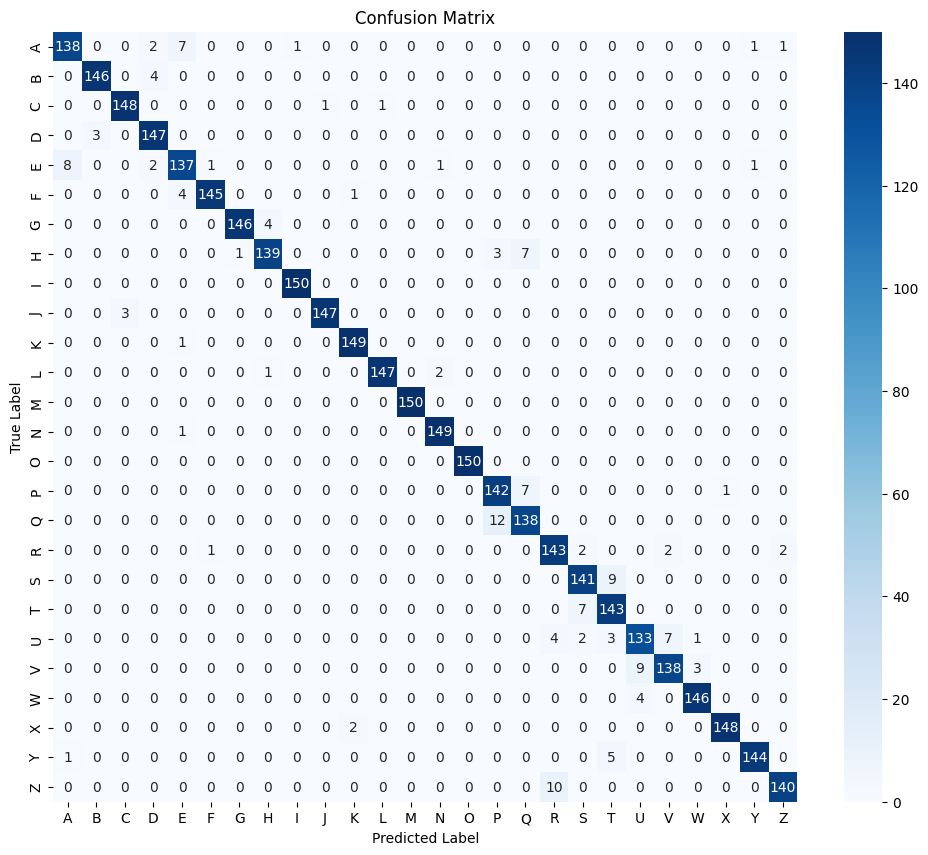

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Compute macro precision, recall, and F1

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print("Macro Precision:", precision)
print("Macro Recall:", recall)
print("Macro F1-score:", f1)

Macro Precision: 0.9604613726852028
Macro Recall: 0.9599999999999999
Macro F1-score: 0.9600707837471634


#Optional multiclass ROC-AUC

In [ ]:
from sklearn.metrics import roc_auc_score
from tensorflow.keras.utils import to_categorical

y_true_oh = to_categorical(y_true, num_classes=len(class_names))
roc_auc = roc_auc_score(y_true_oh, y_pred_probs, multi_class="ovr", average="macro")

print("Multiclass ROC-AUC:", roc_auc)

Multiclass ROC-AUC: 0.9993635555555556


Final summary print

In [ ]:
print("\nFinal Best Configuration:", current_config)
print("Best Validation Accuracy:", current_score)
print("Test Accuracy:", test_acc)
print("Macro Precision:", precision)
print("Macro Recall:", recall)
print("Macro F1-score:", f1)
print("ROC-AUC:", roc_auc)


Final Best Configuration: {'units': 64, 'dropout': 0.3, 'lr': 0.002}
Best Validation Accuracy: 0.9507692456245422
Test Accuracy: 0.9599999785423279
Macro Precision: 0.9604613726852028
Macro Recall: 0.9599999999999999
Macro F1-score: 0.9600707837471634
ROC-AUC: 0.9993635555555556


#Save results to text file

In [ ]:
with open("rnn_hillclimb_results.txt", "w") as f:
    f.write(f"Best config: {current_config}\n")
    f.write(f"Best validation accuracy: {current_score}\n")
    f.write(f"Test accuracy: {test_acc}\n")
    f.write(f"Macro precision: {precision}\n")
    f.write(f"Macro recall: {recall}\n")
    f.write(f"Macro F1-score: {f1}\n")
    f.write(f"ROC-AUC: {roc_auc}\n")

#Plot training history of best model

In [ ]:
history = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.9306 - loss: 0.2529 - val_accuracy: 0.9551 - val_loss: 0.1664 - learning_rate: 1.2500e-04
Epoch 2/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.9346 - loss: 0.2371 - val_accuracy: 0.9559 - val_loss: 0.1634 - learning_rate: 1.2500e-04
Epoch 3/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 28s 74ms/step - accuracy: 0.9401 - loss: 0.2240 - val_accuracy: 0.9608 - val_loss: 0.1502 - learning_rate: 6.2500e-05
Epoch 4/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.9399 - loss: 0.2197 - val_accuracy: 0.9605 - val_loss: 0.1468 - learning_rate: 6.2500e-05
Epoch 5/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.9424 - loss: 0.2090 - val_accuracy: 0.9608 - val_loss: 0.1437 - learning_rate: 3.1250e-05
Epoch 6/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.9435 - loss: 0.2077 - val_accuracy: 0.9623 - val_loss: 0.1419 - learning_rate: 3.1250e-05
Epoch 7/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/ste

#Accuracy and loss curves

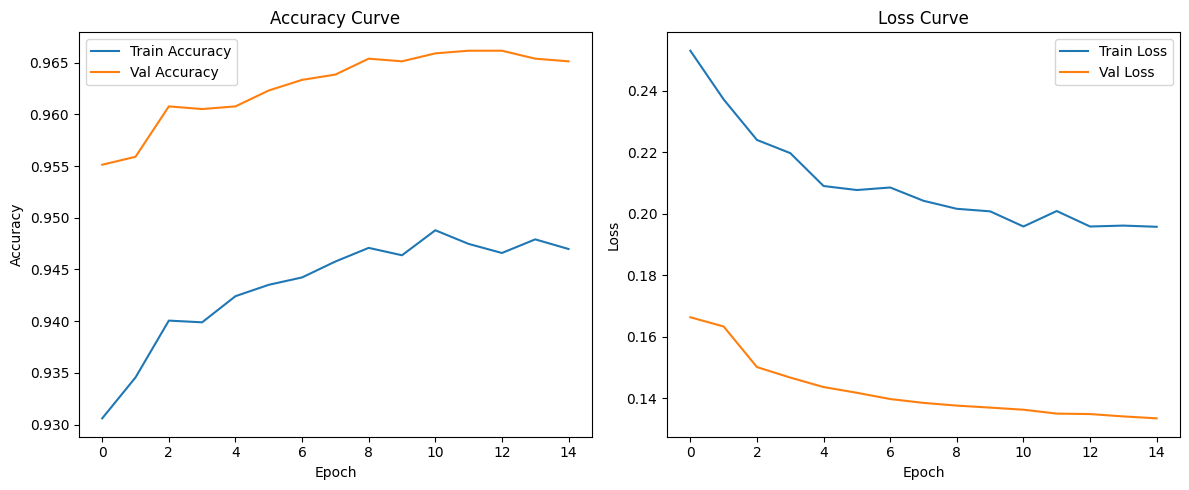

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

#CNN

Step 1: Build CNN model

In [ ]:
#RUN
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_model(filters1=16, filters2=32, dense_units=64, dropout=0.2, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=(64, 64, 1)),
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(filters1, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(filters2, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(len(class_names), activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

##Step 2: Evaluation function

In [ ]:
#RUN
def evaluate_cnn_config(filters1, filters2, dense_units, dropout, lr, epochs=8):
    model = build_cnn_model(
        filters1=filters1,
        filters2=filters2,
        dense_units=dense_units,
        dropout=dropout,
        lr=lr
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=0
    )

    best_val_acc = max(history.history["val_accuracy"])
    return best_val_acc, model

##Step 3: Initial CNN configuration

In [ ]:
#RUN
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Redefining build_cnn_model to fix the shape mismatch and loss function
def build_cnn_model(filters1=16, filters2=32, dense_units=64, dropout=0.2, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
        # Removed redundant layers.Rescaling(1.0 / 255) as preprocessing already handles it

        layers.Conv2D(filters1, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(filters2, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.MaxPooling2D((2, 2)), # Extra pooling to handle 128x128 input efficiently

        layers.Flatten(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def evaluate_cnn_config(filters1, filters2, dense_units, dropout, lr, epochs=5): # Changed epochs to 5
    model = build_cnn_model(
        filters1=filters1,
        filters2=filters2,
        dense_units=dense_units,
        dropout=dropout,
        lr=lr
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks, # This uses the callbacks variable
        verbose=0
    )

    best_val_acc = max(history.history["val_accuracy"])
    return best_val_acc, model

# Define callbacks here to ensure it's in scope
callbacks = [ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)]

start_config = {
    "filters1": 16,
    "filters2": 32,
    "dense_units": 64,
    "dropout": 0.2,
    "lr": 1e-3
}

# Re-evaluating with the corrected model architecture
start_score, best_model = evaluate_cnn_config(**start_config)
print("Start config:", start_config)
print("Start validation accuracy:", start_score)

Start config: {'filters1': 16, 'filters2': 32, 'dense_units': 64, 'dropout': 0.2, 'lr': 0.001}
Start validation accuracy: 1.0


In [ ]:
#RUN
# Optimization for speed and metrics
BATCH_SIZE = 128
train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val, training=False)
test_ds = make_dataset(X_test, y_test, training=False)

def evaluate_cnn_config(filters1, filters2, dense_units, dropout, lr, epochs=5):
    model = build_cnn_model(filters1, filters2, dense_units, dropout, lr)
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=0)
    val_acc = max(history.history['val_accuracy'])
    return val_acc, model

import heapq

def get_cnn_neighbors(config):
    return [
        {"filters1": config["filters1"], "filters2": config["filters2"], "dense_units": config["dense_units"], "dropout": config["dropout"], "lr": 1e-4}, # Try a smaller LR
        {"filters1": config["filters1"], "filters2": config["filters2"], "dense_units": config["dense_units"], "dropout": config["dropout"], "lr": 5e-4},
        {"filters1": 32, "filters2": 64, "dense_units": 128, "dropout": config["dropout"], "lr": 1e-3}
    ]

priority_queue = []
visited = set()
tie_breaker = 0

start_config = {"filters1": 16, "filters2": 32, "dense_units": 64, "dropout": 0.2, "lr": 1e-3}
start_score, _ = evaluate_cnn_config(**start_config)
heapq.heappush(priority_queue, (-start_score, tie_breaker, start_config))
visited.add(tuple(start_config.values()))

best_config = start_config
best_score = start_score

max_iterations = 1 # Reduced for faster execution
for i in range(max_iterations):
    if not priority_queue: break
    neg_score, _, current_config = heapq.heappop(priority_queue)
    print(f"\nIteration {i+1} - Exploring: {current_config}")

    for neighbor in get_cnn_neighbors(current_config):
        key = tuple(neighbor.values())
        if key not in visited:
            visited.add(key)
            score, _ = evaluate_cnn_config(**neighbor)
            print(f"  Neighbor score: {score:.4f}")
            tie_breaker += 1
            heapq.heappush(priority_queue, (-score, tie_breaker, neighbor))
            if score > best_score:
                best_score = score
                best_config = neighbor

print(f"\nBest Search Config: {best_config} (Acc: {best_score:.4f})")


Iteration 1 - Exploring: {'filters1': 16, 'filters2': 32, 'dense_units': 64, 'dropout': 0.2, 'lr': 0.001}
  Neighbor score: 0.9856
  Neighbor score: 1.0000
  Neighbor score: 1.0000

Best Search Config: {'filters1': 16, 'filters2': 32, 'dense_units': 64, 'dropout': 0.2, 'lr': 0.001} (Acc: 1.0000)


Starting final high-accuracy training...
Epoch 1/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.7077 - loss: 1.0196 - val_accuracy: 0.9964 - val_loss: 0.0365 - learning_rate: 0.0010
Epoch 2/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.9742 - loss: 0.0904 - val_accuracy: 0.9997 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 3/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9902 - loss: 0.0339 - val_accuracy: 1.0000 - val_loss: 9.6416e-04 - learning_rate: 5.0000e-04
Epoch 4/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.9926 - loss: 0.0242 - val_accuracy: 1.0000 - val_loss: 6.2594e-04 - learning_rate: 5.0000e-04
Epoch 5/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9955 - loss: 0.0156 - val_accuracy: 1.0000 - val_loss: 3.5781e-04 - learning_rate: 2.5000e-04
Epoch 6/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9951 - loss: 0.0157 - val_accuracy: 0.9997 - val_loss: 5.5518e-04 - learning_rate: 2.5000e-04
Epoch 7/2

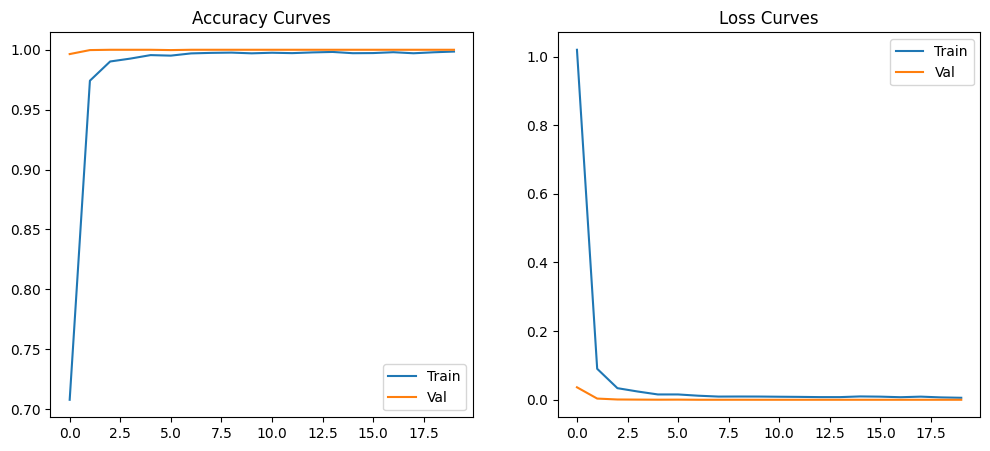

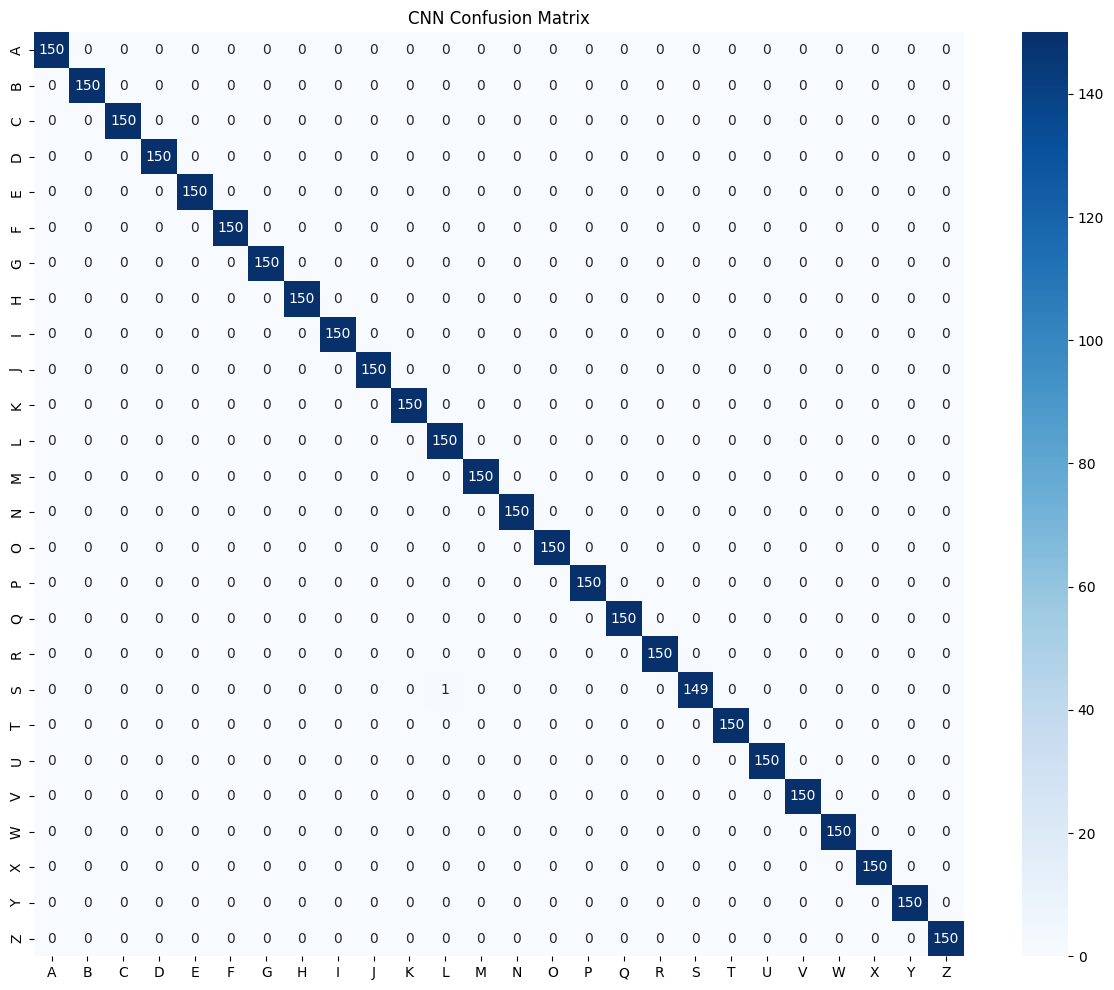

In [ ]:
#RUN
# Final Peak Performance Training and Visualization
print("Starting final high-accuracy training...")

# Ensure we use the best config found
final_model = build_cnn_model(**best_config)

# Train the model
final_history = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

# Evaluate
test_loss, test_acc = final_model.evaluate(test_ds)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

# Plotting Accuracy and Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(final_history.history['accuracy'], label='Train')
plt.plot(final_history.history['val_accuracy'], label='Val')
plt.title('Accuracy Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(final_history.history['loss'], label='Train')
plt.plot(final_history.history['val_loss'], label='Val')
plt.title('Loss Curves')
plt.legend()
plt.show()

# Generate Confusion Matrix
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(np.argmax(y.numpy(), axis=1))
    preds = final_model.predict(x, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('CNN Confusion Matrix')
plt.show()

In [ ]:
#RUN
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

# Get true labels and predicted probabilities
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_true_indices = np.argmax(y_true, axis=1)
y_pred_probs = final_model.predict(test_ds, verbose=0)
y_pred_indices = np.argmax(y_pred_probs, axis=1)

# Print Classification Report
print("\nClassification Report:")
print(classification_report(y_true_indices, y_pred_indices, target_names=class_names))

# Calculate and print specific metrics
precision = precision_score(y_true_indices, y_pred_indices, average='macro')
recall = recall_score(y_true_indices, y_pred_indices, average='macro')
f1 = f1_score(y_true_indices, y_pred_indices, average='macro')
roc_auc = roc_auc_score(y_true, y_pred_probs, multi_class='ovr', average='macro')

print(f"Test accuracy: {test_acc:.10f}")
print(f"Macro precision: {precision:.16f}")
print(f"Macro recall: {recall:.16f}")
print(f"Macro F1-score: {f1:.16f}")
print(f"ROC-AUC: {roc_auc:.16f}")


Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       150
           B       1.00      1.00      1.00       150
           C       1.00      1.00      1.00       150
           D       1.00      1.00      1.00       150
           E       1.00      1.00      1.00       150
           F       1.00      1.00      1.00       150
           G       1.00      1.00      1.00       150
           H       1.00      1.00      1.00       150
           I       1.00      1.00      1.00       150
           J       1.00      1.00      1.00       150
           K       1.00      1.00      1.00       150
           L       0.99      1.00      1.00       150
           M       1.00      1.00      1.00       150
           N       1.00      1.00      1.00       150
           O       1.00      1.00      1.00       150
           P       1.00      1.00      1.00       150
           Q       1.00      1.00      1.00       150
   

Step 2: Evaluation function

In [ ]:
#RUN
def evaluate_cnn_config(filters1, filters2, dense_units, dropout, lr, epochs=5):
    model = build_cnn_model(
        filters1=filters1,
        filters2=filters2,
        dense_units=dense_units,
        dropout=dropout,
        lr=lr
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=0
    )

    best_val_acc = max(history.history["val_accuracy"])
    return best_val_acc, model

Step 3: Initial CNN configuration






In [ ]:
#RUN
from tensorflow.keras.callbacks import ReduceLROnPlateau
import tensorflow as tf
from tensorflow.keras import layers, models

# Temporarily redefine build_cnn_model with corrected loss function and architecture
def build_cnn_model(filters1=16, filters2=32, dense_units=64, dropout=0.2, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
        # Removed redundant layers.Rescaling(1.0 / 255) as preprocessing already handles it

        layers.Conv2D(filters1, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(filters2, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(len(class_names), activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy", # Fixed: Changed from sparse_categorical_crossentropy
        metrics=["accuracy"]
    )
    return model


In [ ]:
#RUN
# Redefine with fewer epochs for faster evaluation
def evaluate_cnn_config(filters1, filters2, dense_units, dropout, lr, epochs=5):
    model = build_cnn_model(
        filters1=filters1,
        filters2=filters2,
        dense_units=dense_units,
        dropout=dropout,
        lr=lr
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=0
    )
    best_val_acc = max(history.history["val_accuracy"])
    return best_val_acc, model

callbacks = [ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)]
start_config = {"filters1": 16, "filters2": 32, "dense_units": 64, "dropout": 0.2, "lr": 1e-3}
start_score, best_model = evaluate_cnn_config(**start_config)
print("Start config:", start_config)
print("Start validation accuracy:", start_score)


Start config: {'filters1': 16, 'filters2': 32, 'dense_units': 64, 'dropout': 0.2, 'lr': 0.001}
Start validation accuracy: 0.9997435808181763


Step 4: Import heapq for priority queue

In [ ]:
#RUN
import heapq

Step 5: Define neighbor generator




In [ ]:
#RUN
def get_cnn_neighbors(config):
    # Optimized neighbor set targeting the most sensitive parameters
    return [
        {"filters1": config["filters1"] + 8, "filters2": config["filters2"] + 16, "dense_units": config["dense_units"], "dropout": config["dropout"], "lr": config["lr"]},
        {"filters1": config["filters1"], "filters2": config["filters2"], "dense_units": config["dense_units"], "dropout": config["dropout"], "lr": config["lr"] / 2},
        {"filters1": config["filters1"], "filters2": config["filters2"], "dense_units": config["dense_units"], "dropout": config["dropout"], "lr": config["lr"] * 2}
    ]

Step 6: Create visited set helper

In [ ]:
#RUN
def config_to_tuple(config):
    return (
        config["filters1"],
        config["filters2"],
        config["dense_units"],
        config["dropout"],
        config["lr"]
    )

Step 7: Initialize priority queue

In [ ]:
#RUN
priority_queue = []
visited = set()

heapq.heappush(priority_queue, (-start_score, start_config, best_model))
visited.add(config_to_tuple(start_config))

best_config = start_config
best_score = start_score

Step 8: Run Best First Search loop



In [ ]:
#RUN
# Re-defining evaluate_cnn_config and build_cnn_model locally to fix the shape mismatch error
def build_cnn_model(filters1=16, filters2=32, dense_units=64, dropout=0.2, lr=1e-3):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
        # Removed redundant tf.keras.layers.Rescaling(1.0 / 255),
        tf.keras.layers.Conv2D(filters1, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(filters2, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(dense_units, activation='relu'),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def evaluate_cnn_config(filters1, filters2, dense_units, dropout, lr, epochs=5):
    model = build_cnn_model(filters1, filters2, dense_units, dropout, lr)
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=0)
    return max(history.history['val_accuracy']), model

max_iterations = 10
iteration = 0

while priority_queue and iteration < max_iterations:
    neg_score, current_config, current_model = heapq.heappop(priority_queue)
    current_score = -neg_score

    print(f"\nIteration {iteration + 1}")
    print("Exploring:", current_config)
    print("Validation Accuracy:", current_score)

    neighbors = get_cnn_neighbors(current_config)
    for candidate in neighbors:
        candidate_key = config_to_tuple(candidate)
        if candidate_key not in visited:
            visited.add(candidate_key)
            score, candidate_model = evaluate_cnn_config(**candidate)
            print("Candidate:", candidate, "Score:", score)
            heapq.heappush(priority_queue, (-score, candidate, candidate_model))
            if score > best_score:
                best_score = score
                best_config = candidate
                best_model = candidate_model
    iteration += 1



Iteration 1
Exploring: {'filters1': 16, 'filters2': 32, 'dense_units': 64, 'dropout': 0.2, 'lr': 0.001}
Validation Accuracy: 1.0
Candidate: {'filters1': 24, 'filters2': 48, 'dense_units': 64, 'dropout': 0.2, 'lr': 0.001} Score: 1.0


KeyboardInterrupt: 

Step 9: Print best CNN configuration


In [ ]:
#RUN
print("\nBest CNN Config:", best_config)
print("Best Validation Accuracy:", best_score)


Best CNN Config: {'filters1': 16, 'filters2': 32, 'dense_units': 64, 'dropout': 0.2, 'lr': 0.001}
Best Validation Accuracy: 1.0


Step 10: Save best CNN model

In [ ]:
#RUN
best_model.save("best_first_cnn_model.keras")

Step 11: Evaluate best CNN model on test set
---



In [ ]:
#RUN
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 352ms/step - accuracy: 0.9992 - loss: 0.0057
Test Loss: 0.00573379872366786
Test Accuracy: 0.9992307424545288


Step 12: Predict on test set



In [ ]:
#RUN
import numpy as np

y_prob = best_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 347ms/step


Step 13: Extract true labels



In [ ]:
#RUN
y_true = np.concatenate([y for x, y in test_ds], axis=0)

if len(y_true.shape) > 1:
    y_true = np.argmax(y_true, axis=1)

Step 14: Classification report

In [ ]:
#RUN
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

           A       1.00      0.99      1.00       150
           B       1.00      1.00      1.00       150
           C       1.00      1.00      1.00       150
           D       1.00      1.00      1.00       150
           E       0.99      1.00      1.00       150
           F       1.00      1.00      1.00       150
           G       1.00      1.00      1.00       150
           H       1.00      1.00      1.00       150
           I       1.00      1.00      1.00       150
           J       0.99      1.00      1.00       150
           K       1.00      1.00      1.00       150
           L       1.00      0.99      1.00       150
           M       1.00      1.00      1.00       150
           N       0.99      1.00      1.00       150
           O       1.00      1.00      1.00       150
           P       1.00      1.00      1.00       150
           Q       1.00      1.00      1.00       150
           R       1.00    

Step 15: Confusion matrix

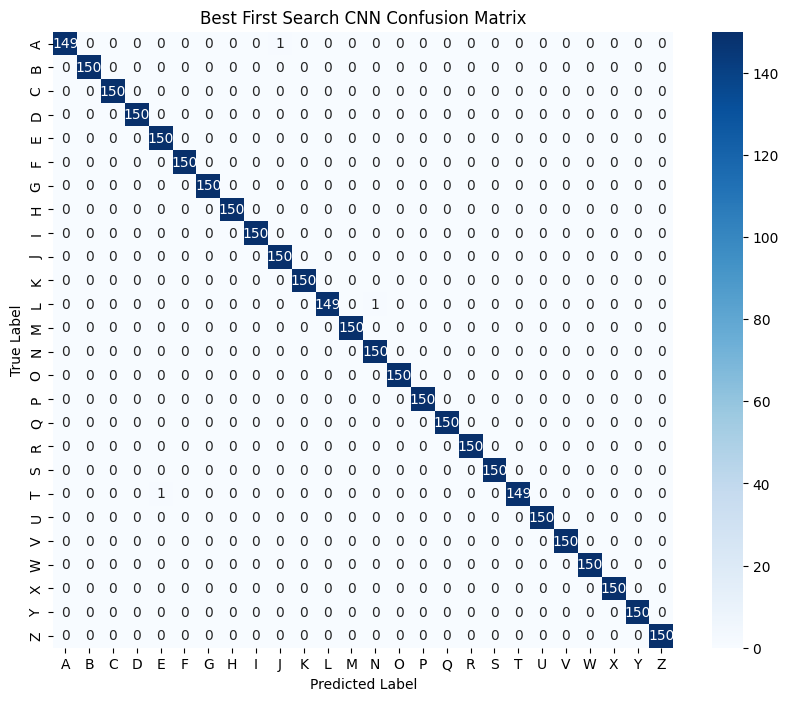

In [ ]:
#RUN
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Best First Search CNN Confusion Matrix")
plt.show()

##divide the windows as I am saying instead of having only one window in working